-------------

> Bueno pues vamos a volver a empezar con otro prototipo de mejora de Daowa-Maad
> PD: Todo el código anterior está en mi GitHub, en el tag v3.0 rc-1 

-------------

In [1]:
from huggingface_hub import login
from dotenv import load_dotenv
import os

load_dotenv()

token = os.getenv("hf_token")
login(token)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [2]:
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
#                                           $
#  Importación de librerías                 $
#                                           $
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$

import timm
import datetime
import cv2
import numpy as np
import torch
import pandas as pd
from typing import Any
from rich.progress import Progress
from torch import nn
from PIL import Image
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.transforms import InterpolationMode, functional

--------------------------------

> Para esta prueba usaremos albumentations y darle más peso a la clase borde, para observar sus resultados

-------------------------------

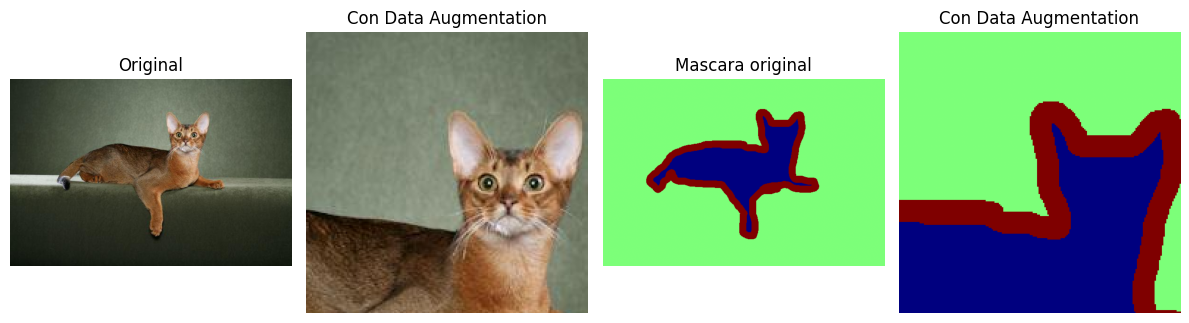

In [3]:
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
#                                                                        $ 
# Muestra de Data Augmentation (Mismos parámetros para el entrenamiento) $
#                                                                        $  
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$

import albumentations as A
import cv2
import matplotlib.pyplot as plt

transform = A.Compose([
    A.RandomCrop(height=192, width=192),
    A.HorizontalFlip(p=0.3),
    A.CoarseDropout(
        num_holes_range=(1, 8),
        hole_height_range=(0.05, 0.15),
        hole_width_range=(0.05, 0.15),
        p=0.3
    ),
])

img = cv2.imread('data/image/images/Abyssinian_1.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

mascara = cv2.imread('data/image/masks/Abyssinian_1.png', cv2.IMREAD_GRAYSCALE)

resultado = transform(image=img, mask = mascara)
trans_img = resultado['image']
trans_mascara = resultado['mask']

fig, ax = plt.subplots(1, 4, figsize=(12, 5))
ax[0].imshow(img)
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].imshow(trans_img)
ax[1].set_title('Con Data Augmentation')
ax[1].axis('off')

ax[2].imshow(mascara, cmap='jet', vmin=0, vmax=2)
ax[2].set_title('Mascara original')
ax[2].axis('off')

ax[3].imshow(trans_mascara, cmap='jet', vmin=0, vmax=2)
ax[3].set_title('Con Data Augmentation')
ax[3].axis('off')


plt.tight_layout()
plt.show()

In [4]:
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
#                                                                             $
# Generación de parámetros para ajustar el learning rate el encoder y decoder $
#                                                                             $
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
from utils.models.daowa_maadV3Prueba import Daowa_maadPrueba

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

modelo = Daowa_maadPrueba(num_clases=3)
modelo = modelo.to(device)
modelo.load_state_dict(torch.load("../Models/ModeloPrueba2026-03-12_2.pth"))
#summary(modelo)

# 1. Parámetros del encoder (ConvNeXtV2 preentrenado)
encoder_params = list(modelo.encoder.parameters())


# 2. Todo lo que NO sea encoder (attention gates, upsampling, head, etc.)
encoder_ids = set(id(p) for p in encoder_params)
decoder_params = [p for p in modelo.parameters() if id(p) not in encoder_ids]


# 3. Verificar que no se perdió ningún parámetro
print(f"Encoder: {len(encoder_params)} tensores")
print(f"Decoder: {len(decoder_params)} tensores")
print(f"Total modelo: {sum(p.numel() for p in modelo.parameters()):,} parámetros")

optimizer = torch.optim.AdamW([
    {'params': encoder_params, 'lr': 5e-5, 'weight_decay': 1e-4},   # Pre-trained → LR bajo
    {'params': decoder_params, 'lr': 5e-4, 'weight_decay': 1e-4},    # Tu decoder → LR normal
])

Encoder: 196 tensores
Decoder: 65 tensores
Total modelo: 37,165,257 parámetros


In [5]:
from utils.losses.dice_loss import GeneralizedDiceLossFN
from utils.train.trainer import train_model
from utils.models.datasets import get_dataloaders
from torchinfo import summary

losses = [
    torch.nn.CrossEntropyLoss(weight=torch.tensor([1.0, 1.0, 1.5]).to(device)),
    GeneralizedDiceLossFN(target_classes=3, epsilon=1e-6)
]

dataloaders = get_dataloaders(batch_size=16, shuffle=False, num_workers=4, shape_img=(384, 384), gold_weight= 0.0)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-6)

train_model(
    modelo = modelo,
    loss_fn = losses,
    optimizador = optimizer,
    dataloaders = dataloaders,
    device_calc = device,
    scheduler = scheduler,
    epochs = 20,
    epsilon = 1e-8
)

Output()

[i] WeightedRandomSampler activo: gold_weight=0.0x
    ├── Normales  : 5906
    └── is_gold   : 91
Iniciando entrenamiento


c:\Users\PC\Desktop\Abbadon\env\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


---- Nuevo mejor modelo con IoU Global: 0.8139 ---

Epoch 1: Train Loss = 0.3098; Precision = 89.03%; Val Loss = 0.4623, Val Acc = 93.36%, mIoU = 0.8139

...

Epoch 19: Train Loss = 0.1572; Precision = 95.37%; Val Loss = 0.4551, Val Acc = 94.47%, mIoU = 0.8370

LRs: 1.30e-06, 4.07e-06 | IoU por Clase: Mascota=0.8956, Fondo=0.9500, Borde=0.6653

Epoch 20: Train Loss = 0.1566; Precision = 95.37%; Val Loss = 0.4535, Val Acc = 94.49%, mIoU = 0.8375

LRs: 1.00e-06, 1.00e-06 | IoU por Clase: Mascota=0.8960, Fondo=0.9503, Borde=0.6662

'Entrenamiento completado'

c:\Users\PC\Desktop\Abbadon\env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Segoe UI.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\PC\Desktop\Abbadon\env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Segoe UI.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\PC\Desktop\Abbadon\env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) Segoe UI.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\PC\Desktop\Abbadon\env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128062 (\N{PAW PRINTS}) missing from font(s) Segoe UI.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\PC\Desktop\Abbadon\env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Segoe UI.
  fig.canvas.print_figure(byte

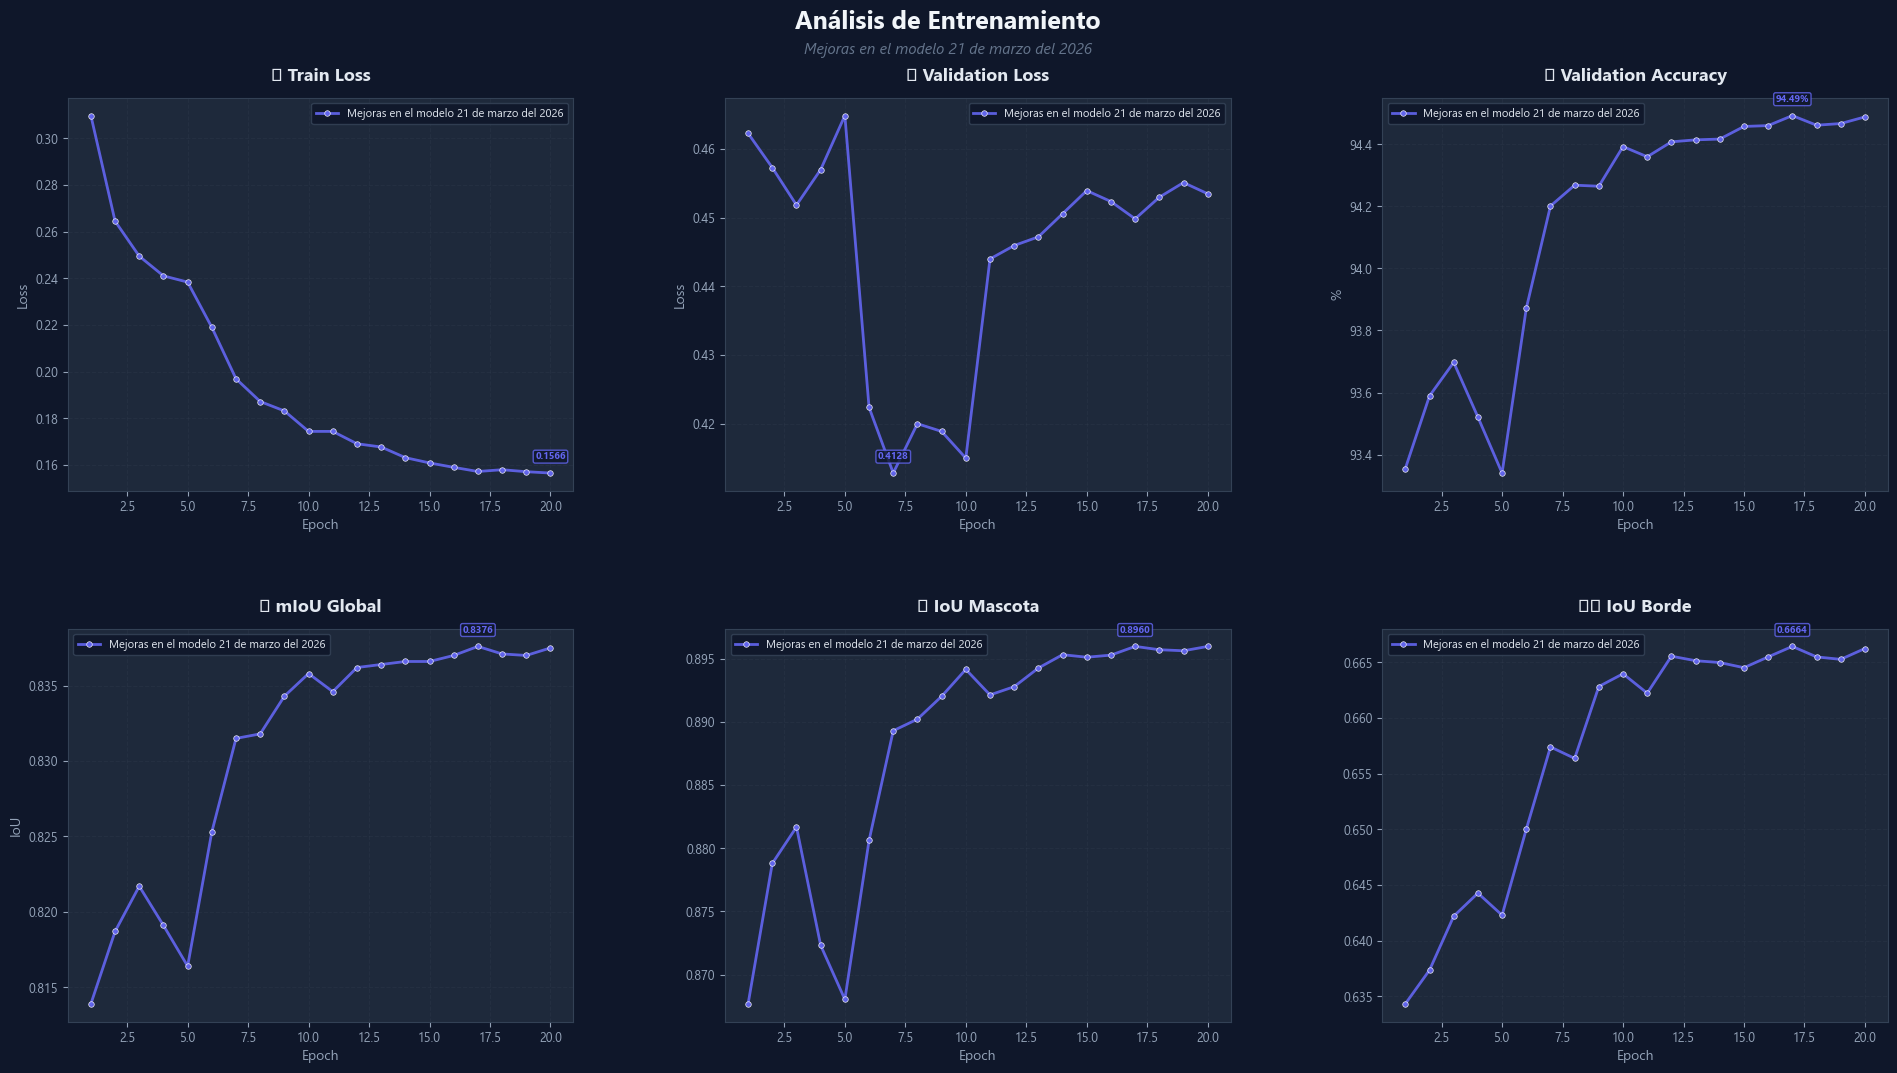


  📊 RESUMEN COMPARATIVO — Mejor epoch de cada modelo
Métrica                   Mejoras en el modelo 21 de marzo del 2026
--------------------------------------------
  Mejor epoch                             17
  Val Loss                            0.4498
  Val Accuracy                        94.49%
  mIoU Global                         0.8376
  IoU Mascota                         0.8960
  IoU Fondo                           0.9504
  IoU Borde ⚠️                        0.6664


In [8]:
from utils.visualization.compare import comparar_entrenamientos

comparar_entrenamientos(
    ('logs/training_history2026-03-21.csv', 'Mejoras en el modelo 21 de marzo del 2026')
)